In [ ]:
import os
train_path = "Training"
test_path = "Testing"
print("Training Classes:")
print(os.listdir(train_path))
print("\nTesting Classes:")
print(os.listdir(test_path))

Training Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Testing Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    "Training",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    "Training",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    "Testing",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(4, activation='softmax'))

print("CNN Model Created Successfully!")

CNN Model Created Successfully!


C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [ ]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
import os

print(os.listdir())

['app.py', 'BrainTumorDetection.ipynb', 'BrainTumorModel.h5', 'Testing', 'Training']


In [ ]:
import os
import cv2
import numpy as np

X = []
y = []

categories = ['glioma', 'meningioma', 'notumor', 'pituitary']

for category in categories:

    path = 'Training/' + category

    label = categories.index(category)

    for img in os.listdir(path):

        img_path = path + '/' + img

        image = cv2.imread(img_path)

        image = cv2.resize(image, (128,128))

        X.append(image)
        y.append(label)

print("Images Loaded Successfully!")

Images Loaded Successfully!


In [ ]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(5600, 128, 128, 3)
(5600,)


In [ ]:
X = X / 255.0

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4480, 128, 128, 3)
(1120, 128, 128, 3)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Recompiled Successfully!")

Model Recompiled Successfully!


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 252ms/step - accuracy: 0.7154 - loss: 0.7286 - val_accuracy: 0.8268 - val_loss: 0.4592
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 255ms/step - accuracy: 0.8815 - loss: 0.3077 - val_accuracy: 0.9000 - val_loss: 0.3047
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 259ms/step - accuracy: 0.9400 - loss: 0.1641 - val_accuracy: 0.8973 - val_loss: 0.3179
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 250ms/step - accuracy: 0.9663 - loss: 0.0912 - val_accuracy: 0.9187 - val_loss: 0.2747
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 248ms/step - accuracy: 0.9821 - loss: 0.0582 - val_accuracy: 0.9196 - val_loss: 0.3041
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step - accuracy: 0.9935 - loss: 0.0261 - val_accuracy: 0.9009 - val_loss: 0.3649
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - accuracy: 0.9955 - loss: 0.0184 - val_accuracy: 0.9187 - val_loss: 0.3358
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 250ms/step - accuracy: 0.9964 - loss: 0

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9339 - loss: 0.2865
Final Test Accuracy: 0.9339285492897034


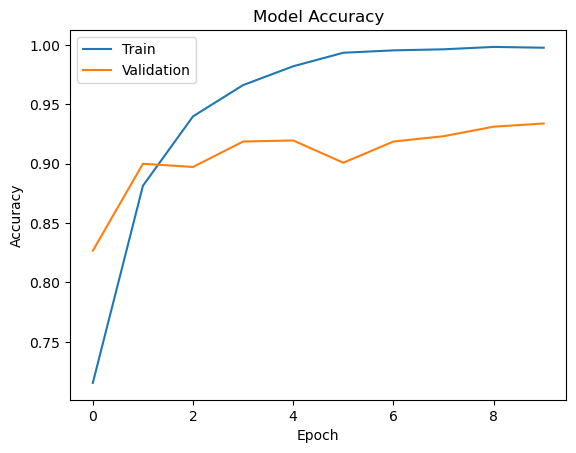

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
import os

print(os.listdir('Testing'))

['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
print(os.listdir('Testing/glioma')[:5])

['Te-gl_1.jpg', 'Te-gl_10.jpg', 'Te-gl_100.jpg', 'Te-gl_101.jpg', 'Te-gl_102.jpg']


In [ ]:
test_image = cv2.imread('Testing/glioma/Te-gl_1.jpg')

test_image = cv2.resize(test_image, (128,128))

test_image = test_image / 255.0

test_image = np.expand_dims(test_image, axis=0)

prediction = model.predict(test_image)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
[[1.08526329e-07 1.45630185e-02 9.85436738e-01 1.14729026e-07]]


In [ ]:
predicted_class = np.argmax(prediction)

categories = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("Predicted Tumor Type:")
print(categories[predicted_class])

Predicted Tumor Type:
notumor


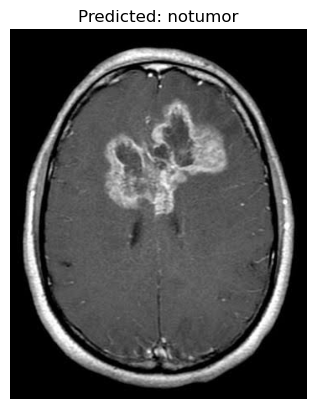

In [ ]:
import cv2
import matplotlib.pyplot as plt

test_image = cv2.imread('Testing/glioma/Te-gl_1.jpg')

plt.imshow(test_image)

plt.title("Predicted: notumor")

plt.axis('off')

plt.show()